In [29]:
import json

import seaborn as sns
sns.set_style("darkgrid")

import pandas as pd

from IPython.display import display

In [30]:
# CONFIGURATION
# =============
# Add/remove LLMs here.
LLMS = [
    {'name': 'Mistral-7B-v0.1',              'pretty': 'Mistral-7B-v0.1',              'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Llama-8B', 'pretty': 'DeepSeek-R1-Distill-Llama-8B', 'num_layers': 32},
    {'name': 'Qwen3-8B',                     'pretty': 'Qwen3-8B',                     'num_layers': 36},
    {'name': 'Llama-2-7b-hf',                'pretty': 'Llama-2-7b-hf',                'num_layers': 32},
    {'name': 'OLMo-2-1124-7B-Instruct',      'pretty': 'OLMo-2-1124-7B-Instruct',      'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Qwen-7B',  'pretty': 'DeepSeek-R1-Distill-Qwen-7B',  'num_layers': 28},
    {'name': 'Llama-3.1-8B-Instruct',        'pretty': 'Llama-3.1-8B-Instruct',        'num_layers': 32},
]

# Specify the probing setting
PROBE_SETTING = 'int_sci_compare'  # e.g., 'dec_dec_compare', 'int_sci_compare'

# Offsets for each probe type
OFFSET_REGRESSION = 'mixed_offset_0'       # e.g., 'mixed_offset_0', 'int_offset_0', 'sci_offset_0' for int-sci comparison
OFFSET_CLASSIFICATION = 'last_token'       # e.g., 'last_token', 'concat_offset_0'

# Where to save figures
SAVE_FIG_PATH = '../figures/'

# Which split to use
SPLIT = 'val'

# Which verbalization setting to use (should match PROBE_SETTING)
VERBALIZATION_SETTING = PROBE_SETTING


In [31]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# # Create save directory
# os.makedirs(SAVE_FIG_PATH, exist_ok=True)
# os.makedirs(os.path.join(SAVE_FIG_PATH, "layerwise", PROBE_SETTING), exist_ok=True)
# os.makedirs(os.path.join(SAVE_FIG_PATH, "correlation", PROBE_SETTING), exist_ok=True)

def get_verbalization_results(llm, setting, alt=False, n_few_shot=1, operator="max"):
    """Load verbalization results for a given LLM and setting."""

    assert operator in ["max", "min"], f"Unsupported operator {operator}"

    exp_name = f"{n_few_shot}-shot" + ("-alt" if alt else "") + (f"-{operator}" if operator == "min" else "")

    path = os.path.join(
        "..",
        "verbalization",
        "few-shot-sweeping",
        exp_name,
        f"{llm}",
        f"{setting}.jsonl"
    )
    if not os.path.exists(path):
        # print(f'Warning: {path} not found!')
        return None
    with open(path, 'r') as f:
        results = [json.loads(line) for line in f]
    # print(f"Loaded: {path}")
    return results


In [32]:
dfs = {}

for llm in LLMS:
    name = llm['name']
    dfs[name] = []
    for n_few_shot in [1, 2, 3, 4, 5]:
        for postfix in ["", "-alt", "-min"]:
            alt = "alt" in postfix
            operator = "min" if "min" in postfix else "max"
            results = get_verbalization_results(name, VERBALIZATION_SETTING, n_few_shot=n_few_shot, alt=alt, operator=operator)

            if results is None:
                print(f"WARNING: not results found for {n_few_shot}-shot{postfix} with model {name}")
                continue

            df = pd.DataFrame(results[2:])
            for k, v in {'model': name, 'alt': alt, 'n_few_shot': n_few_shot, "operator": operator}.items():
                df[k] = v
            dfs[name].append(df)

In [33]:
df = pd.concat(sum([dflist for dflist in dfs.values()], []))
print(df.shape)

(123200, 11)


In [34]:
import re

def extract_answer(row):
    number_regex = r'\d+(?:,\d{3})*(?:\.\d+)?(?:\s*[×x*]\s*10\^?-?\d+)?'

    output = row['model_output']
    n_few_shot = row['n_few_shot']
    answer_part = output.split('A:')[n_few_shot+1].strip()
    numbers = re.findall(number_regex, answer_part)
    if numbers:
        return numbers[0]
    else:
        return None


df["extracted_answer"] = df.apply(extract_answer, axis=1)

In [35]:
(df["extracted_answer"] == None).any()

np.False_

In [36]:
def eval_value_str(value_str):
    return float(eval(value_str.replace('×', '*').replace('^', '**').replace(',', '')))

df["a"] = df["a"].astype('string')
df["b"] = df["b"].astype('string')

df["a_val"] = df["a"].apply(eval_value_str)
df["b_val"] = df["b"].apply(eval_value_str)

df["log_ratio"] = np.log2(df["a_val"]) - np.log2(df["b_val"])

df["extracted_answer_val"] = df["extracted_answer"].apply(eval_value_str)
df["answered_a"] = df.apply(lambda x: np.isclose(x["extracted_answer_val"], x["a_val"]), axis=1)
df["answered_b"] = df.apply(lambda x: np.isclose(x["extracted_answer_val"], x["b_val"]), axis=1)
df["answered_neither"] = df.apply(lambda x: not (x["answered_a"] or x["answered_b"]), axis=1)

df["is_answer_sci"] = df["extracted_answer"].apply(lambda x: "×" in x)

In [37]:
def is_comparison_correct(row):
    true_a = row["a_val"]
    true_b = row["b_val"]

    model_value = row["extracted_answer_val"]

    if row["operator"] == "max":
        comparison_correct = (
            (true_a > true_b and abs(model_value - true_a) < 1e-3) or
            (true_b > true_a and abs(model_value - true_b) < 1e-3)
        )
    else:
        comparison_correct = (
            (true_a < true_b and abs(model_value - true_a) < 1e-3) or
            (true_b < true_a and abs(model_value - true_b) < 1e-3)
        )

    return comparison_correct

df["comparison_correct"] = df.apply(is_comparison_correct, axis=1)

In [38]:
def few_shot_log_ratio_plot(df, title, ax=None):
    if ax is None:
        ax = plt.gca()

    sns.lineplot(
        data=df.groupby([
            "n_few_shot",
            pd.cut(df["log_ratio"], bins=np.arange(-21, 23, 2) / 10).apply(lambda x: x.right-0.1),
        ], observed=True)["comparison_correct"].mean().reset_index(),
        x="log_ratio",
        y="comparison_correct",
        hue="n_few_shot",
        ax=ax,
        palette="Accent"
    ).set_title(title)
    ax.set_xlabel("$\\log(a/b)$")
    ax.set_ylabel("Accuracy")
    ax.set_yticks(np.arange(0, 11, 1) / 10)

    handles, labels = ax.get_legend_handles_labels()
    label_to_color = {label: handle.get_color() for handle, label in zip(handles, labels)}
    for n_few_shot in range(1, max(map(int, label_to_color.keys()))+1):
        color = label_to_color[str(n_few_shot)]
        acc = df.query(f"n_few_shot == {n_few_shot}")["comparison_correct"].mean()
        ax.axhline(y=acc, color=color, linestyle='--', alpha=0.7)


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

sns.set_theme(style="darkgrid")
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10

In [40]:
from matplotlib.font_manager import FontProperties

In [41]:
# Load GPT-4.1 and GPT-4.1-mini results
import re
def load_answers(llm, setting, num_shot=1):
    suffix = f"_{num_shot}shot" if num_shot > 1 else ""
    path = f'../verbalization-test/{setting}_output_{llm}{suffix}.txt' 
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f]

def eval_value_str(value_str):
    return float(eval(value_str.replace('×', '*').replace('^', '**').replace(',', '')))


def parse_answer(s):
    if s is None:
        return None
    s = s.strip()
    if not s:
        return None

    # normalize symbols
    s = s.replace('×', '*').replace('^', '**').replace('x', '*')
    s = s.replace(',', '')  # remove thousands separator
    s = s.replace(' ', '')

    # if it's not a number-like string, return None
    # allow patterns like 5.7*10**2 or 580 or 3.14
    if not re.search(r'\d', s):
        return None

    try:
        return float(eval(s))
    except:
        try:
            return float(s)
        except:
            return None

def make_api_df(llm, setting, template_df, num_shot=1):
    answers = load_answers(llm, setting, num_shot)

    df_api = template_df.copy()

    # clear probe-related column

    df_api['answer'] = answers
    df_api['answer_num'] = df_api['answer'].apply(parse_answer)  # per-row parse
    # compute correctness: did model output the larger number?
    larger = df_api[['a_val', 'b_val']].max(axis=1)

    diff = (df_api['answer_num'] - larger).abs()      # Series
    df_api['comparison_correct'] = (diff <= 5e-5).fillna(False)
    df_api['model'] = llm
    df_api['has_probes'] = False
    return df_api

API_models = ['GPT-4.1', 'GPT-4.1-mini']
gpt_answers = load_answers('GPT-4.1', VERBALIZATION_SETTING)
print(gpt_answers[:10])
# copy one existing model's results to keep the structure
# but set all columns after "model" to None and rewrite these two columns: "comparison_correct" and "model"
template = df[df['model'] == 'Mistral-7B-v0.1']  # or any existing model df with correct rows/order
df['has_probes'] = True
for n_few_shot in [1, 2, 3, 4, 5]:
    template = df.query(f"model == 'Mistral-7B-v0.1' and operator == 'max' and alt == False and n_few_shot == {n_few_shot}")
    df_gpt41 = make_api_df('GPT-4.1', VERBALIZATION_SETTING, template, num_shot=n_few_shot)
    df_gpt41mini = make_api_df('GPT-4.1-mini', VERBALIZATION_SETTING, template, num_shot=n_few_shot)
    df = pd.concat([df, df_gpt41, df_gpt41mini], ignore_index=True)

print("verbalization results for GPT-4.1 and GPT-4.1-mini):")
print("=" * 20)
for n_few_shot in [1, 2, 3, 4, 5]:
    for API_model in API_models:
        llm = API_model
        llmdf = df[(df["model"] == llm) & (df["n_few_shot"] == n_few_shot)]
        test_acc = llmdf["comparison_correct"].mean()
        print("model: {:<30}  few-shot: {:<2}  test acc: {:.6f}".format(llm, n_few_shot, test_acc))



['53', '26', '28', '4.5 × 10^1', '7.8 × 10^1', '8 × 10^1', '96', '5.9 × 10^1', '8.7 × 10^1', '80']


verbalization results for GPT-4.1 and GPT-4.1-mini):
model: GPT-4.1                         few-shot: 1   test acc: 0.941875
model: GPT-4.1-mini                    few-shot: 1   test acc: 0.921250
model: GPT-4.1                         few-shot: 2   test acc: 0.955625
model: GPT-4.1-mini                    few-shot: 2   test acc: 0.966250
model: GPT-4.1                         few-shot: 3   test acc: 0.955625
model: GPT-4.1-mini                    few-shot: 3   test acc: 0.963125
model: GPT-4.1                         few-shot: 4   test acc: 0.961875
model: GPT-4.1-mini                    few-shot: 4   test acc: 0.966250
model: GPT-4.1                         few-shot: 5   test acc: 0.970000
model: GPT-4.1-mini                    few-shot: 5   test acc: 0.963750


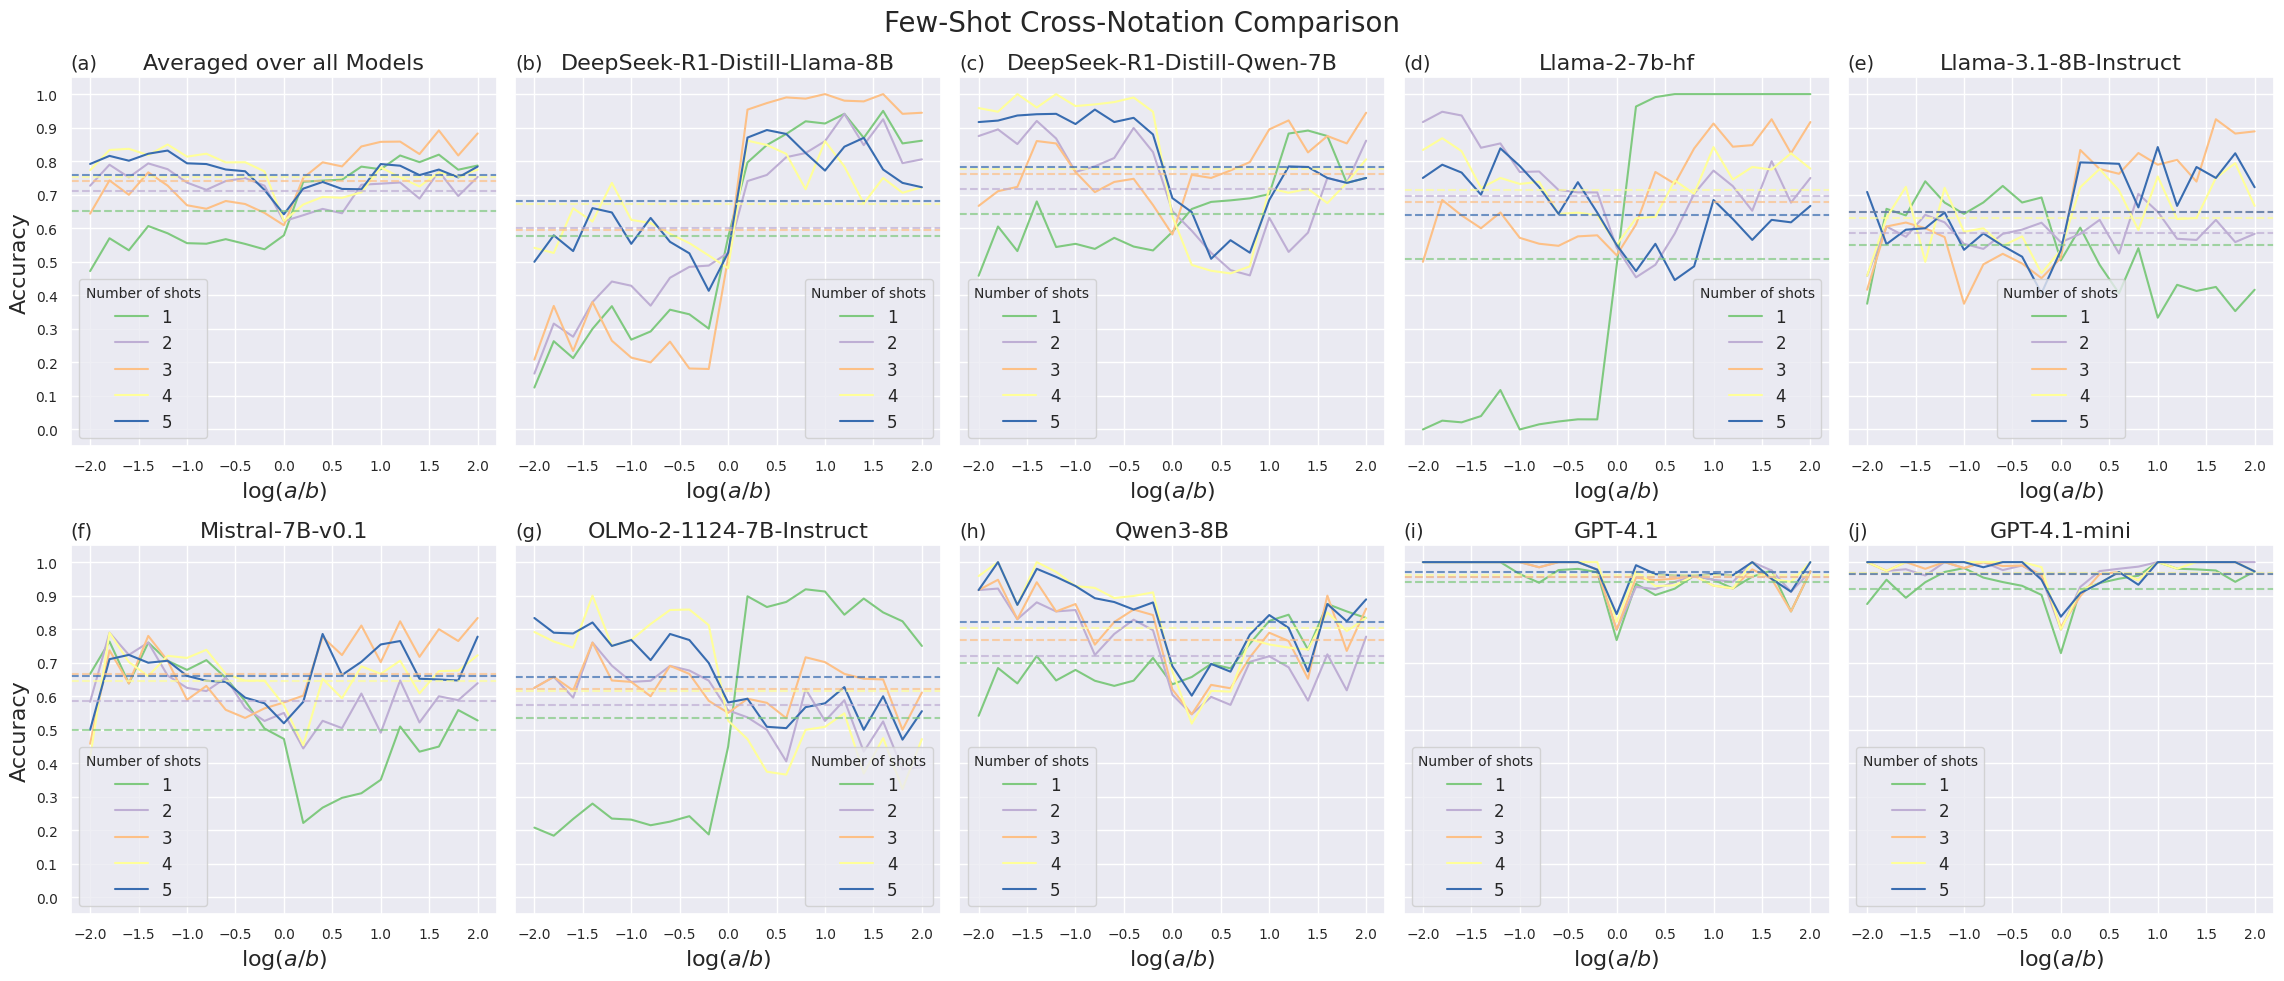

In [42]:
ALL_FIG_DIR = "../figures/"

fig, axes = plt.subplots(2, 5, figsize=(23, 10), sharey=True)

few_shot_log_ratio_plot(df.query("operator == 'max' and alt == False"), "Averaged over all Models", ax=axes[0, 0])

LLMS = [
    {'name': 'DeepSeek-R1-Distill-Llama-8B', 'pretty': 'DeepSeek-R1-Distill-Llama-8B', 'num_layers': 32},
    {'name': 'DeepSeek-R1-Distill-Qwen-7B',  'pretty': 'DeepSeek-R1-Distill-Qwen-7B',  'num_layers': 28},
    {'name': 'Llama-2-7b-hf',                'pretty': 'Llama-2-7b-hf',                'num_layers': 32},
    {'name': 'Llama-3.1-8B-Instruct',        'pretty': 'Llama-3.1-8B-Instruct',        'num_layers': 32},
    {'name': 'Mistral-7B-v0.1',              'pretty': 'Mistral-7B-v0.1',              'num_layers': 32},
    {'name': 'OLMo-2-1124-7B-Instruct',      'pretty': 'OLMo-2-1124-7B-Instruct',      'num_layers': 32},
    {'name': 'Qwen3-8B',                     'pretty': 'Qwen3-8B',                     'num_layers': 36},
    {'name': 'GPT-4.1',                      'pretty': 'GPT-4.1',                      'num_layers': 32},
    {'name': 'GPT-4.1-mini',                 'pretty': 'GPT-4.1-mini',                 'num_layers': 32},
]

for idx, llm in enumerate(LLMS):
    idx += 1  # offset the first average plot
    llm_name = llm["name"]
    llmdf = df[df["model"] == llm_name].query("operator == 'max' and alt == False")
    few_shot_log_ratio_plot(
        llmdf, llm_name, axes[idx // 5, idx % 5]
    )

for idx in range(axes.size):
    ax = axes[idx // 5, idx % 5]
    label = chr(ord('a') + idx)  # 'a', 'b', 'c', ...
    ax.set_title(f'({label})', fontsize=14, loc='left')

    legend = ax.get_legend()
    legend.set_title("Number of shots", prop=FontProperties(size=10))

fig.suptitle("Few-Shot Cross-Notation Comparison", size=20)

plt.tight_layout()
fig_dir = os.path.join(ALL_FIG_DIR, "log_ratio_plot")
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir, exist_ok=True)

plt.savefig(os.path.join(fig_dir, "few_shot_log_ratio_plot.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(fig_dir, "few_shot_log_ratio_plot.png"), bbox_inches="tight")

In [43]:
# Q: why gpt-4.1-mini only has two dashed lines
# A: a couple of them are too close

llmdf = df[df["model"] == "GPT-4.1-mini"].query("operator == 'max' and alt == False")
sorted(llmdf["n_few_shot"].unique())
llmdf.groupby("n_few_shot")["comparison_correct"].mean()

n_few_shot
1    0.921250
2    0.966250
3    0.963125
4    0.966250
5    0.963750
Name: comparison_correct, dtype: float64